In [1]:
from finite_key import *
from collections.abc import Callable
import typing

data_dir = pathlib.Path.home().joinpath(
    # 'Heriot-Watt University Team Dropbox',
    # 'RES_EPS_EMQL',
    # 'projects',
    # 'Optical ground station',
    # '__software__',
    # 'finite_key',
    'Projects',
    'Finite_key_data'
).resolve()

loss_profile_dir = data_dir.joinpath('550000m_0m_0.25m').resolve()
loss_profiles = get_loss_profiles(dir=loss_profile_dir)
loss_profile = get_loss_profile(
    max_elevation=90,
    loss_profiles=loss_profiles
)

power_range = np.linspace(0, 10, 100)

dc_range_10km = range(0,401,10)
dc_range_no_fibre = range(200,1401,55)

dc_range = dc_range_10km
params = params_10km_fibre

In [2]:
def _akl_worker(
        total_loss: list[float],
        dc: int,
        params: list[float],
        power: int
) -> typing.Optional[tuple[ int, int, int]]:
    ps = params.copy()
    ps[4] = params[4] * power

    qber, qx, m = neumann.raw_overpass(
        params=ps,
        loss_profile=total_loss,
        DC_B=dc
    )
    akl = (1-1.19*h(qber)-h(qx))/2 * m

    if akl > 0:
        return dc, power, akl
    return None

def _skl_worker(
        total_loss: list[float],
        dc: int,
        params: list[float],
        power: int
) -> typing.Optional[tuple[ int, int, int]]:
    ps = params.copy()
    ps[4] = params[4] * power

    qber, qx, m = neumann.raw_overpass(
        params=ps,
        loss_profile=total_loss,
        DC_B=dc
    )
    m /= 2.0
    delta = (qber + qx) / 2.0

    skl = lim.smart_optimise(
        m=m,
        delta=delta,
        eps_qkd=1e-6,
        t=math.log2(10**8),
        f=1.19
    ) * m

    if skl > 0:
        return dc, power, skl
    return None

In [3]:
def power_kl_dc_data(
        loss_profile: LossProfile,
        params: list[float],
        dc_range: range,
        power_range: np.ndarray,
        func: Callable
) -> tuple[list[int], list[int], list[int]]:
    jobs = []
    for dc in dc_range:
        for power in power_range:
            jobs.append((loss_profile.total_loss, dc, params, power))

    dcs, pwrs, kls = [], [], []
    with ProcessPoolExecutor(max_workers=max_workers) as ex:
        futures = [ex.submit(func, *job) for job in jobs]
        for fut in as_completed(futures):
            res = fut.result()
            if res is None:
                continue
            dc, power, kl = res
            dcs.append(dc)
            pwrs.append(power)
            kls.append(kl)

    return dcs, pwrs, kls

In [4]:
akl_dcs, akl_pwrs, kls = power_kl_dc_data(
    loss_profile=loss_profile,
    params=params,
    dc_range=dc_range,
    power_range=power_range,
    func=_akl_worker
)

In [ ]:
skl_dcs, skl_pwrs, skls = power_kl_dc_data(
    loss_profile=loss_profile,
    params=params,
    dc_range=dc_range,
    power_range=power_range,
    func=_skl_worker
)

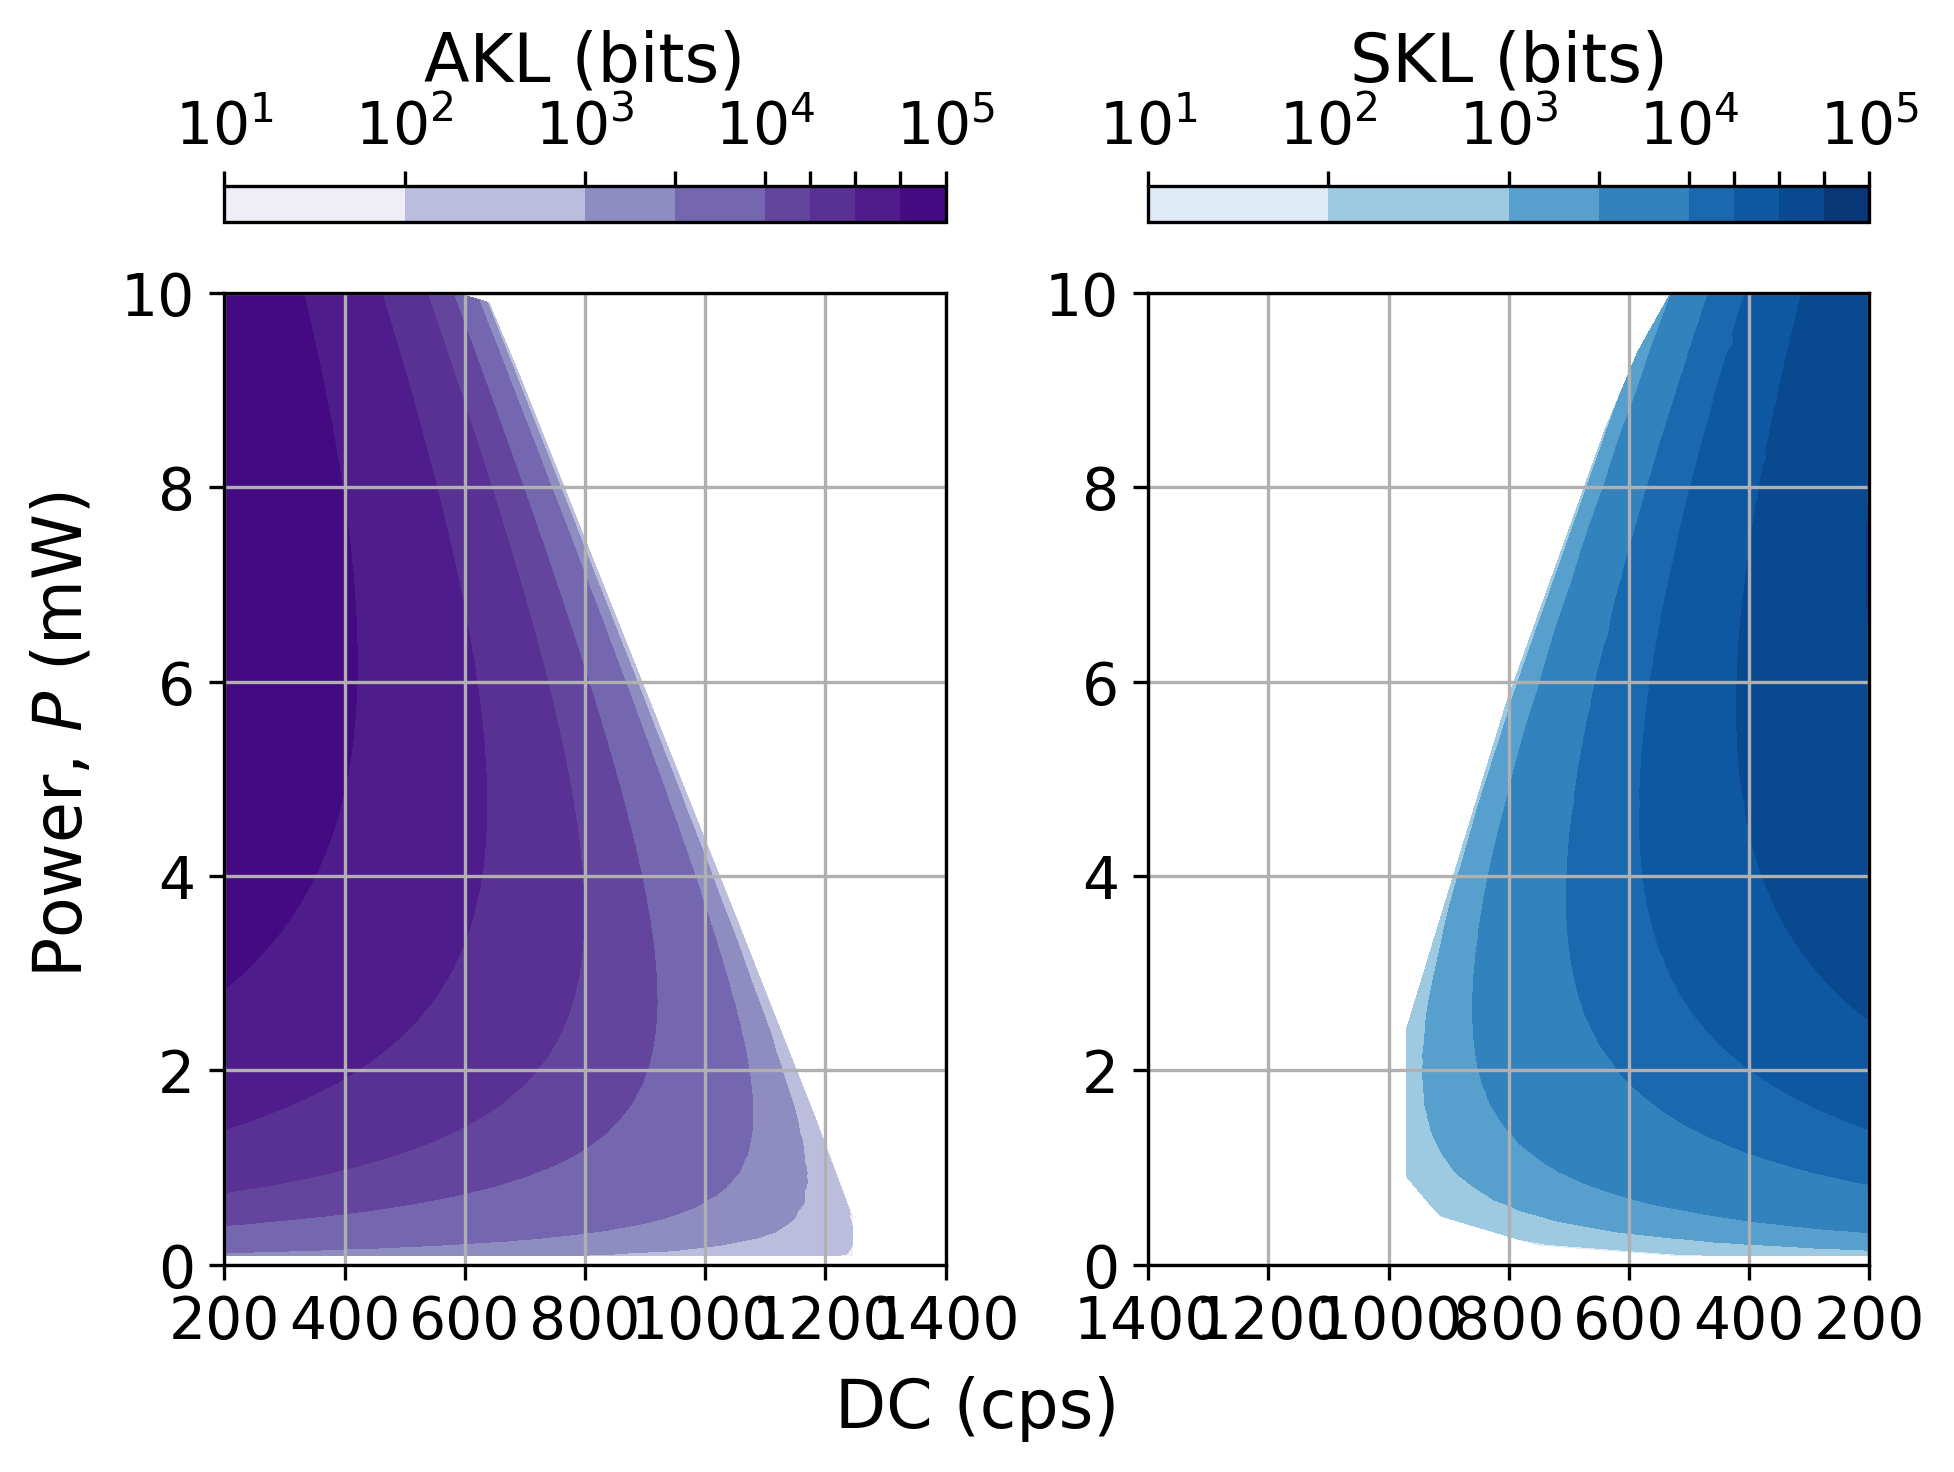

In [ ]:
levels_10km_fibre = [1e1, 1e2, 1e3, 3.16e3, 1e4, 1.78e4, 3.16e4, 5.62e4, 1e5]
levels_no_fibre = [1e1, 1e2, 1e3, 3.16e3, 1e4, 1.78e4, 3.16e4, 5.62e4, 1e5]

levels = levels_10km_fibre

def power_akl_dc(
        dcs: list[int],
        pwrs: list[int],
        akls: list[int],
        fontsize,
        tick_fontsize,
        ax: typing.Optional[axes.Axes] = None
) -> None:
    if ax is None:
        fig, ax = plt.subplots()

    cs = ax.tricontourf(
        dcs,
        pwrs,
        akls,
        levels=levels,
        norm=colors.LogNorm(),
        cmap='Purples'
    )

    ax.tick_params(labelsize=tick_fontsize)
    ax.set_xticks(ticks=range(200, 1401, 400))
    ax.set_yticks(ticks=range(0, 11, 2))
    ax.set_xlim(200,1400)
    ax.grid(visible=True)

    cb = ax.figure.colorbar(
        mappable=cs,
        ax=ax,
        location='top',
        orientation='horizontal',
    )
    cb.ax.tick_params(labelsize=tick_fontsize)
    cb.ax.xaxis.set_ticks_position(position='top')
    cb.set_label(
        label='AKL (bits)',
        fontsize=fontsize
    )
    cb.ax.xaxis.set_label_position(position='top')

def power_skl_dc(
        dcs: list[int],
        pwrs: list[int],
        skls: list[int],
        ax: typing.Optional[axes.Axes] = None,
        fontsize=16,
        tick_fontsize=12
    ) -> None:
    if ax is None:
        fig, ax = plt.subplots()
    
    ang_opt, pow_opt, skl_opt = optimal_power_curve(dcs, pwrs, skls)
    cs = ax.tricontourf(
        dcs,
        pwrs,
        skls,
        levels=levels,
        norm=colors.LogNorm(),
        cmap='Blues'
    )

    ax.tick_params(labelsize=tick_fontsize)
    ax.set_xticks(ticks=range(200, 1401, 400))
    ax.set_yticks(ticks=range(0, 11, 2))
    ax.set_xlim(200,1400)
    ax.grid(visible=True)
    ax.invert_xaxis()

    cb = ax.figure.colorbar(
        mappable=cs,
        ax=ax,
        location='top',
        orientation='horizontal',
    )
    cb.ax.tick_params(labelsize=tick_fontsize)
    cb.ax.xaxis.set_ticks_position(position='top')
    cb.set_label(
        label='SKL (bits)',
        fontsize=fontsize
    )
    cb.ax.xaxis.set_label_position(position='top')

dpi = 300
fontsize = 16
tick_fontsize = 14
filename = 'paper_fig_4.pdf'

fig, ax = plt.subplots(
    nrows=1,ncols=2,
    dpi=dpi,
    constrained_layout=True
)
fig.supxlabel(
    t='DC (cps)',
    fontsize=fontsize
)
fig.supylabel(
    t=r'Power, $P$ (mW)',
    fontsize=fontsize
)

power_akl_dc(
    dcs=akl_dcs,
    pwrs=akl_pwrs,
    akls=kls,
    fontsize=fontsize,
    tick_fontsize=tick_fontsize,
    ax=ax[0]
)
power_skl_dc(
    dcs=skl_dcs,
    pwrs=skl_pwrs,
    skls=skls,
    fontsize=fontsize,
    tick_fontsize=tick_fontsize,
    ax=ax[1]
)
fig.savefig(fname=filename, dpi=dpi)